# 1. Imports

Lets start by getting all our imports, keep in mind that PyTorch is not automatically detects and trains on GPU, you have to tell it to use cuda. In case you want to train on Mac Silicon replace cuda with mps.

In [1]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
import platform
# Local
from data import data

In [2]:
def get_mps() -> str:
    device_name = "mps" if torch.backends.mps.is_available() else "cpu"
    return device_name

In [3]:
def get_cuda() -> str:
    device_name = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return device_name

In [4]:
device = get_mps() if platform.system() == "Darwin" else get_cuda()
print(f"Using device: {device}")

Using device: mps


# 2. Reading Data Paths

The following code will be going through a nested directory structure where images are stored within subdirectories, each directory is representing a specific label (category). It constructs a list of the file paths for these images and their corresponding labels. Then, it creates a pandas DataFrame containing this information, which is useful for further data processing. Keep in mind that we will read all the data and then we will split it again to train, validation and testing.

In [5]:
animal_faces_train_path = data.get_dataset_path("pytorch-image", "raw", "animal_faces_classification_train", 2)
animal_faces_validation_path = data.get_dataset_path("pytorch-image", "raw", "animal_faces_classification_validation", 2)

In [6]:
print(animal_faces_train_path)
print(animal_faces_validation_path)

/../../../../../../Volumes/Workstation/Datasets/PyTorch/image_classification/train
/../../../../../../Volumes/Workstation/Datasets/PyTorch/image_classification/validation


In [7]:
image_path = []
labels = []

for i in os.listdir(animal_faces_train_path):
    if not i.startswith("."):
        for j in os.listdir(f"{animal_faces_train_path}/{i}"):
            if not j.startswith("."):
                image_path.append(f"{animal_faces_train_path}/{i}/{j}")
                labels.append(i)


for i in os.listdir(animal_faces_validation_path):
    if not i.startswith("."):
        for j in os.listdir(f"{animal_faces_validation_path}/{i}"):
            if not j.startswith("."):
                image_path.append(f"{animal_faces_validation_path}/{i}/{j}")
                labels.append(i)

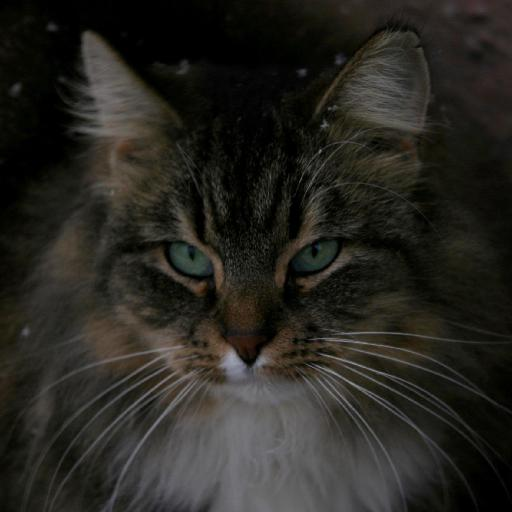

In [8]:
from IPython.display import display


image = Image.open(image_path[0])
display(image)

In [9]:
len(image_path)

16130

In [10]:
data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_paths", "labels"]) # Create a dataframe contains the image paths and the labels
data_df.head() # Visualizing the first 5 rows

,image_paths,labels
0,/../../../../../../Volumes/Workstation/Dataset...,cat
1,/../../../../../../Volumes/Workstation/Dataset...,cat
2,/../../../../../../Volumes/Workstation/Dataset...,cat
3,/../../../../../../Volumes/Workstation/Dataset...,cat
4,/../../../../../../Volumes/Workstation/Dataset...,cat


In [11]:
data_df.shape

(16130, 2)

In [12]:
data_df["labels"].unique()

array(['cat', 'dog', 'wild'], dtype=object)

# 3. Data Split

Now lets split the dataset into training, validation and testing. Here we will be using it in a bit different way since we will be reading the image paths from the dataframe so better we split the dataframe directly and then read the images. We will do that by getting a random sample of 70% from our data using  `data_df.sample(frac=0.7,random_state=7)`  then we will create a new variable of test dataset which we will drop from it the 70% of the train which means that it will be 30% of the data which is the rest of the data using  `data_df.drop(train.index)`. Then we will do the same between testing to create validation which will be 50% of the data which means the final split we have is the following:

-   Training: 70%
-   Validation: 15%
-   Testing: 15%

In [13]:
train=data_df.sample(frac=0.7,random_state=7) # Create training of 70% of the data
test=data_df.drop(train.index) # Create testing by removing the 70% of the train data which will result in 30%

val=test.sample(frac=0.5,random_state=7) # Create validation of 50% of the testing data
test=test.drop(val.index) # Create testing by removing the 50% of the validation data which will result in 50%

In [14]:
print(train.shape)
print(test.shape)
print(val.shape)

(11291, 2)
(2419, 2)
(2420, 2)


# 4. Preprocessing Objects

Now lets create some preprocessing objects, first we start by  `LabelEncoder`  which converts string classes to numeric for example instead of having the classes as (cat, dog) it will be (0,1) because machines understands numbers only. Next we will create an object  `transform`  which will help us to preprocess images by converting all images to same size, converting them to tensors of type float and you can even do more with this object. Feel free to check their documentation  [here](https://pytorch.org/vision/0.9/transforms.html).

In [15]:
label_encoder = LabelEncoder() # Encode the string classes to numeric
label_encoder.fit(data_df['labels']) # Fit the label encoder on our own data

transform = transforms.Compose([
    transforms.Resize((128, 128)), # One size for all images
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.ConvertImageDtype(torch.float) # The values are in floating point numbers
    ]) # Transform all images into one clear format (preprocess all images to the same properties)

# 6. Custom Dataset Class

Let's create a dataset class.
Our class is a customized class on how we can use our own dataset.
The class inherits from the main  `Dataset`  class from PyTorch,
then we overwrite some of the existing functions in that class.
We need to convert our dataset to PyTorch Dataset object as it will be more efficient during training,
you can use the dataset as its, but let's keep things professional and efficient.
First, we define our class that will be taking the main Dataset class with the concept of inheritance as mentioned.
Let's make the concept simpler.
There is a big class that PyTorch, this class has several functions inside it,
we will recreate that class and modify some functions to match our needs.

In the constructor function  `__init__`  we are declaring and our dataframe which will have  `image_path`  and the  `labels`. Then we are creating our own image preprocessing object which is  `transform`  that we talked about before. For our labels, we are declaring our labels with the label_encoder we declared before. Which means that we will convert our labels are changed from string to numeric classes using  `fit_tranform`. We didn't read each image inside the constructor as reading images here will be so time consuming. However, we are reading each image, applying the preprocessing and returning it in the  `__getitem__`  to read this specific image with its corresponding encoded label by their index and returns them.

In [16]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
          image = self.transform(image).to(device)

        return image, label


# 7. Create Dataset Objects

Now lets create 3 data objects, for training data, validation and testing respectively giving them our dataframes we created before together with the  `transform`  object that we created before. We will use the same  `transform`  object to make sure all images are preprocessed as they are.

In [17]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

In [18]:
train_dataset.__len__()

11291

In [19]:
train_dataset.__getitem__(2)

(tensor([[[0.8745, 0.8745, 0.8784,  ..., 0.8588, 0.8588, 0.8549],
          [0.8824, 0.8824, 0.8824,  ..., 0.8667, 0.8627, 0.8588],
          [0.8863, 0.8902, 0.8902,  ..., 0.8706, 0.8706, 0.8667],
          ...,
          [0.5765, 0.5765, 0.6039,  ..., 0.3490, 0.3569, 0.3569],
          [0.5765, 0.5843, 0.6235,  ..., 0.3490, 0.3569, 0.3647],
          [0.5765, 0.5961, 0.6667,  ..., 0.3490, 0.3569, 0.3647]],
 
         [[0.8745, 0.8745, 0.8784,  ..., 0.8588, 0.8588, 0.8549],
          [0.8824, 0.8824, 0.8824,  ..., 0.8667, 0.8627, 0.8588],
          [0.8863, 0.8902, 0.8902,  ..., 0.8706, 0.8706, 0.8667],
          ...,
          [0.6627, 0.6471, 0.6745,  ..., 0.4353, 0.4431, 0.4431],
          [0.6627, 0.6471, 0.6745,  ..., 0.4353, 0.4431, 0.4510],
          [0.6588, 0.6510, 0.7020,  ..., 0.4353, 0.4431, 0.4510]],
 
         [[0.8667, 0.8667, 0.8706,  ..., 0.8510, 0.8510, 0.8471],
          [0.8745, 0.8745, 0.8745,  ..., 0.8588, 0.8549, 0.8510],
          [0.8784, 0.8824, 0.8824,  ...,

In [20]:
label_encoder.inverse_transform([1])

array(['dog'], dtype=object)


# 8. Visualize Images

This cell is optional and will not affect the model accuracy. Here we are just visualizing 9 random images using  `matplotlib`  package.

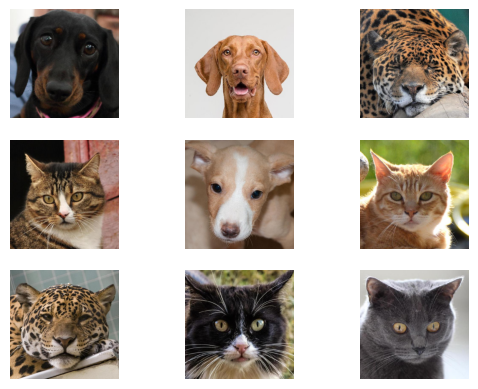

In [21]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()


# 9. Hyperparameters

Now we are setting the training hyperparameters, we defined some variables which are the batch size, number of training epochs and learning rate.

In [22]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10


# 10. DataLoaders

PyTorch provides a class called DataLoader which allows us to create objects of it to simplify the training.

Dataloader is an object that we can loop through it to train according to batches. When we start training, we loop through epochs, if you skip the batch size it means that the amount of training data in one batch is equal to the complete amount of training data, this method is not efficient and in most of the cases you need to train through using batches. Dataloader allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the  `shuffle`  to randomize the data and then you can loop through it in each epoch to train normally.

In [23]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 11. Model

Now we will build our CNN Network. We will be building it by creating a class that inherits from  `nn.Module`  and we will create our layers. Additionally, we will overwrite the  `forward`  function to modify our forward propagation. The model will start by having a 2-d convolution neural network that will have input channels of 3 which is the RGB input channels. Outputting 32 feature map. Then another 2-d convolution neural network taking 32 channels and outputting 64 and finally another one taking 64 channels and outputting 128 feature map. Each 2-d convolution neural network will be followed by a max pooling layer of size 2x2 and a  `ReLU`  activation function.

After that we will have a  `flatten`  layer to vectorize these feature maps followed by a linear layer which will have shape of (128, 16, 16) which means 128 feature map each one is 16x16 as the image started by 128x128 and got divided by 2 three times after each pooling layers. finally we will have an output  `linear`  layer with the length of the unique values of the labels.

In [24]:
class Net(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1) # First Convolution layer
      self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1) # Second Convolution layer
      self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1) # Third Convolution layer

      self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
      self.relu = nn.ReLU() # ReLU Activation function

      self.flatten = nn.Flatten() # Flatten and vectorize the output feature maps that somes from the final convolution layer.
      self.linear = nn.Linear((128 * 16 * 16), 128) # Traditional Dense (Linear)
      self.output = nn.Linear(128, len(data_df['labels'].unique())) # Output Linear Layer


    def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)

      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)

      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)

      x = self.flatten(x)
      x = self.linear(x)
      x = self.output(x)

      return x

model = Net().to(device) # Create an instance of the model and move it to the GPU Device


# 12. Model Summary

This cell is optional, here we show only the summary of the model and what is the output size for each layer. keep in mind that -1 here will be replaced by the batch size.

In [31]:
from torchinfo import summary

summary(model, input_size=(1, 3, 128, 128), device=device)


Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 3]                    --
├─Conv2d: 1-1                            [1, 32, 128, 128]         896
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ReLU: 1-3                              [1, 32, 64, 64]           --
├─Conv2d: 1-4                            [1, 64, 64, 64]           18,496
├─MaxPool2d: 1-5                         [1, 64, 32, 32]           --
├─ReLU: 1-6                              [1, 64, 32, 32]           --
├─Conv2d: 1-7                            [1, 128, 32, 32]          73,856
├─MaxPool2d: 1-8                         [1, 128, 16, 16]          --
├─ReLU: 1-9                              [1, 128, 16, 16]          --
├─Flatten: 1-10                          [1, 32768]                --
├─Linear: 1-11                           [1, 128]                  4,194,432
├─Linear: 1-12                           [1, 3]                    38